# nyquist and alising
- **Topics**: What is the minimum sampling rate required to faithfully reconstruct a signal?
- **Applied to**: RF, Audio, ADCs, SDRs — any system that digitises a real-world signal
- **Blog**: Sampling, Nyquist & Alising

# The Nyquist Sampling Therom
A continous time-signal can be reconstructed from its samples,     
if sampled at rate grater than **twice** its highest frequency component.

$$ f_s > 2f_{\text{max}} $$


- where $ f_s $ is the sampling rate and 
- $ f_{\text{max}} $ is the highest frequency in the signal. 

**Practical Application**: In audio, CDs use a sampling rate of 44.1 kHz to capture frequencies up to 20 kHz    
(the upper limit of human hearing), ensuring $ 2 \times 20,\text{kHz} = 40,\text{kHz} $, with a safety margin.$, preventing aliasing. 

**Common Misconception**: Sampling exactly at $ 2f_{\text{max}} $ is insufficient; the rate must be strictly greater than $ 2f_{\text{max}} $   
to avoid reconstruction issues, especially for pure sine waves at the Nyquist frequency.  

**Beyond Audio**: The theorem applies to any signal,     
including images (spatial sampling), EEG,and communication systems, ensuring accurate digital representation.

# Nyquist Frequency.

Nyquist frequency is the maximum frequency component of a signal that can be accurately represented and reconstructed by a digital sampling system,    
defined as exactly half of the sampling rate ($f_s/2$)

$$f_{Nyquist} = f_s / 2$$

## Why Does This Work? Proof by Intuition
A sine wave is fully defined by its samples. If two different frequencies produce identical sample values, the sampler cannot distinguish them — information is permanently lost.
The minimum rate that guarantees no two frequencies can produce identical samples is 2f.

# Aliasing

Aliasing is a phenomenon where a signal is incorrectly measured or reconstructed as a lower frequency due to insufficient sampling rates, resulting in false frequencies that were not present in the original signal

This distortion occurs when a continuous signal is sampled at a rate lower than twice the highest frequency contained within it,     
- violating the Nyquist-Shannon sampling theorem $f_{signal} > f_{Nyquist}$     
- $f_{signal} > f_{Nyquist}$, the signal folds back and appears as a lower frequency. 

**The alias formula:** $f_{alias} = |f_{signal} - f_s|$

**Example:** 1 kHz, 4 kHz, 5 kHz at fs = 8000 Hz. Plot all three. Explain what you see in a markdown cell below the plot.

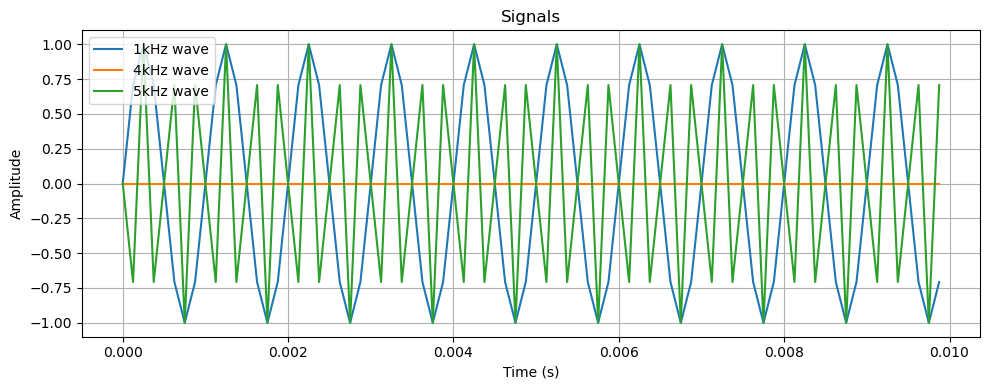

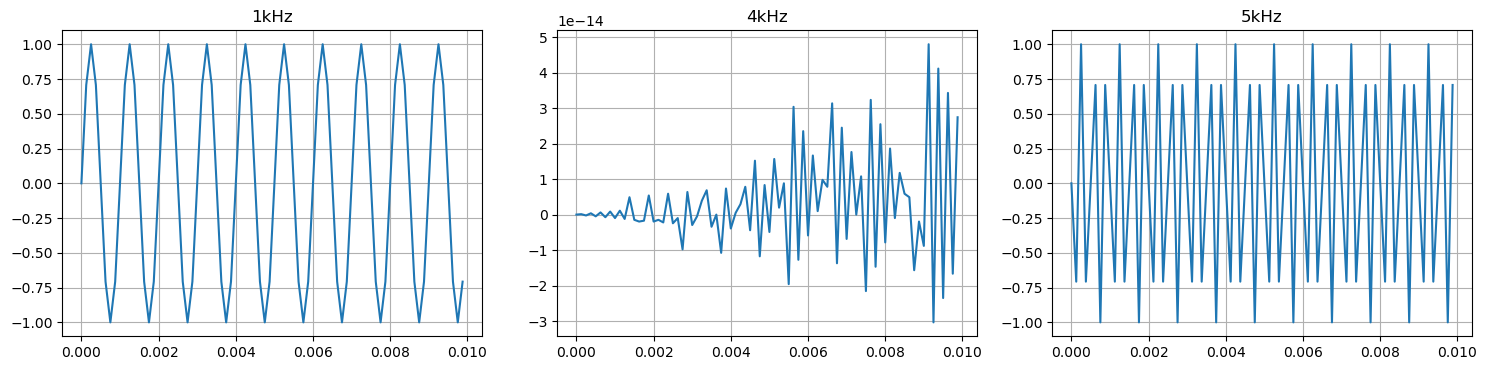

In [32]:
import sys
import os

# Add the parent directory (Rf-Lab) to sys.path
sys.path.append(os.path.abspath('..'))

from core.signal_generator import SignalGenerator
from utils.plotter import Plotter

import matplotlib.pyplot as plt
import numpy as np

sg = SignalGenerator(fs=8000)

t1, sine_1k = sg.sine(frequency=1000, duration=0.01)
t2, sine_4k = sg.sine(frequency=4000, duration=0.01)
t3, sine_5k = sg.sine(frequency=5000, duration=0.01)

signals = [sine_1k, sine_4k, sine_5k]
labels = ["1kHz wave", "4kHz wave", "5kHz wave"]

Plotter.plot_multiple(t1, signals, labels)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

t = t1  # common time axis

axs[0].plot(t, sine_1k)
axs[0].set_title("1kHz")
axs[0].grid(True)

axs[1].plot(t, sine_4k)
axs[1].set_title("4kHz")
axs[1].grid(True)

axs[2].plot(t, sine_5k)
axs[2].set_title("5kHz")
axs[2].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Leave space for suptitle
plt.show()

Given:     
$f_{Nyquist} = 8000/2 => 4000 HZ$    
$f_{1kHz} = 1000 Hz$, $f_{4kHz} = 4000 Hz$, $f_{5kHz}=5000 Hz$    

we can also observe that **1kHz sine wave** is well structured:     
$f_{signal} <= f_{Nyquist}$   
$1000 kHz <= 4000 kHz$

- $[f_1kHz < f_{Nyquist}] => 1000 Hz < 4000 Hz$ so no alising appears.    
- $[f_4kHz <= f_{Nyquist}] => 4000 Hz <= 4000 Hz$ so no alising appears.    
- $[f_5kHz > f_{Nyquist}] => 5000 Hz > 4000 Hz$ so alising appears.   
  
from above graphs we can see that 5kHz signal alias the 3 kHz signal.    
$f_{alias} = |f_{signal} - f_{sample}|$    
$f_{alias_1kHz} = |1000 - 8000| => $ 
$f_{alias} = 3000 Hz$


# Aliasing Analysis

### Given

$
f_s = 8000 \, \text{Hz}
$
$
f_{\text{Nyquist}} = \frac{f_s}{2} = 4000 \, \text{Hz}
$

### Signal Frequencies

$
f_1 = 1000 \, \text{Hz}, \quad
f_2 = 4000 \, \text{Hz}, \quad
f_3 = 5000 \, \text{Hz}
$

### Aliasing Conditions

- If $f_{\text{signal}} < f_{\text{Nyquist}}$ → No aliasing  
- If $f_{\text{signal}} = f_{\text{Nyquist}}$ → Edge case (not reliable)  
- If $f_{\text{signal}} > f_{\text{Nyquist}}$ → Aliasing occurs  

### Analysis

- $f_1 = 1000 < 4000 \Rightarrow \text{No aliasing}$
- $f_2 = 4000 = 4000 \Rightarrow \text{Nyquist edge case}$
- $f_3 = 5000 > 4000 \Rightarrow \text{Aliasing occurs}$


### Aliasing Formula

$
f_{\text{alias}} = \left| f_{\text{signal}} - n f_s \right|
$

where $n \in \mathbb{Z}$ such that $f_{\text{alias}} \in [0, f_{\text{Nyquist}}]$

### Alias Calculation for 5 kHz

$
f_{\text{alias}} = \left| 5000 - 8000 \right| = 3000 \, \text{Hz}
$

### Conclusion

- **1 kHz** → No aliasing  
- **4 kHz** → Nyquist edge case  
- **5 kHz** → Aliases to **3 kHz**

## Nyquist Edge Case (4 kHz Signal)

from above graph why done 4kHz go flat?     
if Nyquist frequency is equal to signal frequiency that i captures exactly two points that lie on the x-axis making it look like flat line

$x[n] = \sin\left(2\pi \cdot \frac{4000}{8000} \cdot n \right)$
$= \sin(\pi n)$
$= 0 \quad \forall \, n \in \mathbb{Z}$

## Key Takeaways
**Cover:**
- The Nyquist rule   
- What aliasing is and why it happens   
- The edge case at exactly Nyquist   
- Real systems use fs>2f_s  
- fs >2f with margin   

Anti-aliasing filters in hardware (high level — detail comes in Phase 4)   


What's Next: Notebook 03 — Fourier Transform & FFT   